# Value Investing Algorithm

A quantitative value investing screener that ranks S&P 500 securities using five fundamental analysis ratios. Each stock is percentile-ranked across all metrics to produce a composite value score, identifying the **top 10 most undervalued securities**.

**Metrics used:** P/E, P/B, P/S, EV/EBITDA, EV/Gross Profit  
**Method:** Percentile scoring across all ratios, averaged into a composite score

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import math
from scipy import stats
import matplotlib.pyplot as plt

## 2. Load Stock Universe

In [2]:
tickers = pd.read_csv("sp500_stocks.csv")
print(f"Loaded {len(tickers)} stocks across {tickers['Sector'].nunique()} sectors")
tickers.head()

Loaded 50 stocks across 9 sectors


,Ticker,Company Name,Sector
0,AAPL,Apple Inc.,Technology
1,MSFT,Microsoft Corporation,Technology
2,GOOGL,Alphabet Inc.,Technology
3,AMZN,Amazon.com Inc.,Technology
4,NVDA,NVIDIA Corporation,Technology


## 3. Fetch Fundamental Data

For each stock, retrieve five valuation ratios from Yahoo Finance:

| Ratio | What it measures |
|-------|------------------|
| **P/E** | Share price relative to earnings per share |
| **P/B** | Market price relative to book value (equity per share) |
| **P/S** | Market valuation relative to total sales |
| **EV/EBITDA** | Enterprise value relative to core operating profitability |
| **EV/GP** | Enterprise value relative to gross profit |

In [3]:
def fetch_values_of_stocks(tickers_list):
    value_columns = [
        "Ticker", "Price", "PE-Ratio", "PB-Ratio", "PS-Ratio", "EV/EBITDA", "EV/GP"
    ]
    value_df = pd.DataFrame(columns=value_columns)

    for ticker in tickers_list:
        stock = yf.Ticker(ticker)
        price = stock.history(period="1d")["Close"].iloc[-1]
        info = stock.info

        pe_ratio = info.get("forwardPE", np.nan)
        pb_ratio = info.get("priceToBook", np.nan)
        ps_ratio = info.get("priceToSalesTrailing12Months", np.nan)

        ev = info.get("enterpriseValue", np.nan)
        ebitda = info.get("ebitda", np.nan)
        ev_ebitda = ev / ebitda if ev and ebitda and ebitda != 0 else np.nan

        gross_margins = info.get("grossMargins", np.nan)
        total_revenue = info.get("totalRevenue", np.nan)
        if gross_margins and total_revenue:
            gross_profit = gross_margins * total_revenue
            ev_gp = ev / gross_profit if ev and gross_profit != 0 else np.nan
        else:
            ev_gp = np.nan

        value_df.loc[len(value_df)] = [
            ticker, price, pe_ratio, pb_ratio, ps_ratio, ev_ebitda, ev_gp
        ]

    return value_df

tickers_list = tickers["Ticker"].values.tolist()
df = fetch_values_of_stocks(tickers_list)
print(f"Fetched fundamental data for {len(df)} stocks")
df.head()

Fetched fundamental data for 50 stocks


,Ticker,Price,PE-Ratio,PB-Ratio,PS-Ratio,EV/EBITDA,EV/GP
0,AAPL,283.779999,29.532974,39.088154,9.232588,26.155060,19.365010
1,MSFT,372.970001,19.256187,6.686806,8.705053,15.276119,12.960760
2,GOOGL,337.390015,23.182789,8.538493,9.744487,25.148487,15.905885
3,AMZN,232.690002,23.550333,5.662522,3.369888,16.652806,6.905294
4,NVDA,192.529999,15.125293,23.857498,18.396193,27.906208,24.574867


## 4. Handle Missing Values

Replace any missing ratio values with the column mean to avoid excluding stocks with partial data.

In [4]:
value_columns = ["PE-Ratio", "PB-Ratio", "PS-Ratio", "EV/EBITDA", "EV/GP"]

for column in value_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df[column] = df[column].fillna(df[column].mean())

print(f"Missing values after cleaning: {df[value_columns].isna().sum().sum()}")

Missing values after cleaning: 0


## 5. Percentile Scoring

Each valuation ratio is percentile-ranked across the universe. A stock's **composite value score** is the average of its five percentile ranks. Lower ratios indicate better value, so higher percentile scores (closer to 1.0) represent cheaper stocks relative to peers.

In [5]:
percentile_metrics = {
    "PE-Ratio": "PE Percentile",
    "PB-Ratio": "PB Percentile",
    "PS-Ratio": "PS Percentile",
    "EV/EBITDA": "EV/EBITDA Percentile",
    "EV/GP": "EV/GP Percentile"
}

for metric, percentile in percentile_metrics.items():
    df[percentile] = df[metric].apply(
        lambda x: stats.percentileofscore(df[metric], x) / 100
    )

df["Value Score"] = df[[p for p in percentile_metrics.values()]].mean(axis=1)
df = df.sort_values("Value Score", ascending=False)
df.reset_index(inplace=True, drop=True)

## 6. Top 10 Undervalued Stocks & Portfolio Allocation

Select the 10 highest-scoring stocks and calculate equal-weight position sizes for a **$500,000 portfolio**.

In [6]:
df = df.head(10)

portfolio_size = 500_000
position_size = portfolio_size / len(df.index)

df["Shares to Buy"] = df["Price"].apply(
    lambda price: math.floor(position_size / price)
)

display_cols = ["Ticker", "Price", "PE-Ratio", "PB-Ratio", "PS-Ratio",
                "EV/EBITDA", "EV/GP", "Value Score", "Shares to Buy"]
df[display_cols].round(2)

,Ticker,Price,PE-Ratio,PB-Ratio,PS-Ratio,EV/EBITDA,EV/GP,Value Score,Shares to Buy
0,TSLA,379.71,151.76,17.34,14.57,126.01,74.91,0.94,131
1,LLY,1208.12,27.16,34.60,14.91,30.80,18.64,0.91,41
2,GE,369.00,42.48,21.32,7.98,35.88,26.31,0.90,135
3,AAPL,283.78,29.53,39.09,9.23,26.16,19.37,0.88,176
4,CAT,997.47,33.13,24.62,6.49,34.29,24.67,0.86,50
5,AVGO,365.02,18.82,19.81,23.01,42.34,30.95,0.84,136
6,MA,499.02,21.91,65.87,12.99,21.13,13.31,0.79,100
7,V,336.23,22.62,18.04,14.86,21.37,15.31,0.79,148
8,GOOGL,337.39,23.18,8.54,9.74,25.15,15.91,0.78,148
9,NVDA,192.53,15.13,23.86,18.40,27.91,24.57,0.77,259


## 7. Visualisation

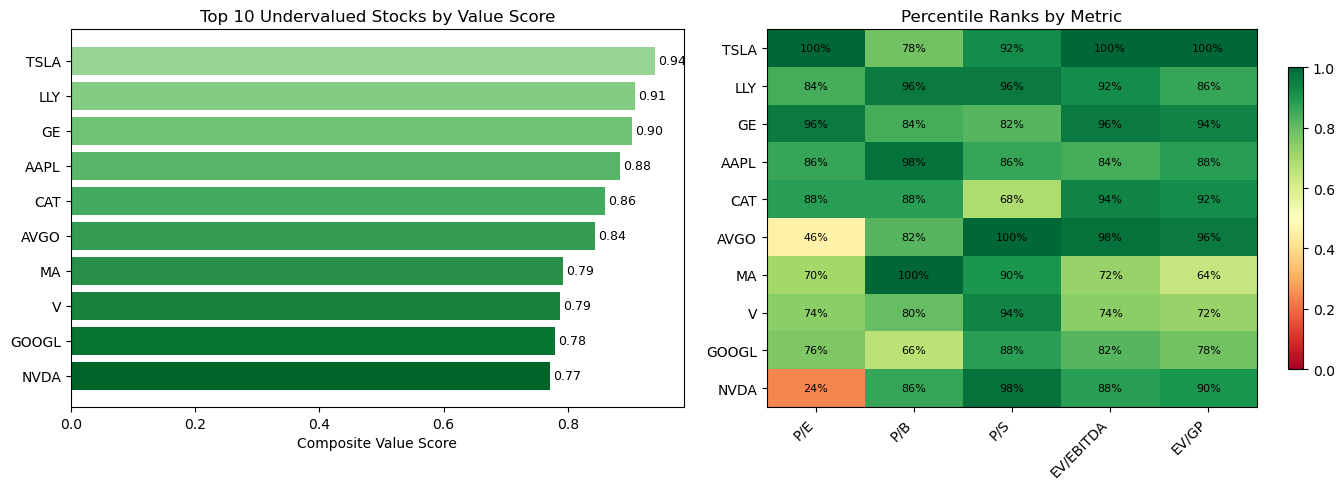

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(df)))

# Value score ranking
axes[0].barh(df["Ticker"], df["Value Score"], color=colors)
axes[0].set_xlabel("Composite Value Score")
axes[0].set_title("Top 10 Undervalued Stocks by Value Score")
axes[0].invert_yaxis()
for i, v in enumerate(df["Value Score"]):
    axes[0].text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)

# Percentile breakdown heatmap-style
percentile_cols = list(percentile_metrics.values())
heatmap_data = df.set_index("Ticker")[percentile_cols]
im = axes[1].imshow(heatmap_data.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_yticks(range(len(df)))
axes[1].set_yticklabels(df["Ticker"])
axes[1].set_xticks(range(len(percentile_cols)))
axes[1].set_xticklabels(["P/E", "P/B", "P/S", "EV/EBITDA", "EV/GP"], rotation=45, ha="right")
axes[1].set_title("Percentile Ranks by Metric")
plt.colorbar(im, ax=axes[1], shrink=0.8)

for i in range(len(df)):
    for j in range(len(percentile_cols)):
        val = heatmap_data.values[i, j]
        axes[1].text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("value_investing_results.png", dpi=150, bbox_inches="tight")
plt.show()